# Modal TabNet PEAD — Updated Results Analysis

This notebook loads the **updated** outputs from `modal_tabnet_pead.py` (class weights, 4Q validation, 60 epochs, train/val/test predictions, feature importance).

## What was saved

| File | Contents | Rows |
|---|---|---|
| `updated_results.parquet` | Per-prediction table (12 columns) | 9,937 test samples across 20 folds |
| `updated_per_fold_summary.parquet` | DA, MAE, RMSE per fold | 20 |
| `updated_histories_clf.json` | Per-epoch loss + LR curves (classifier) | 20 folds × 60 epochs |
| `updated_histories_reg.json` | Per-epoch loss + RMSE curves (regressor) | 20 folds × 60 epochs |
| `updated_feature_importance.json` | Feature importances per fold (CLF + REG) | 20 folds × 258 features |


In [1]:
import json
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=FutureWarning)

# Theme
sns.set_theme(style="whitegrid", context="notebook", rc={
    "figure.dpi": 100, "figure.autolayout": True,
    "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.labelsize": 10, "axes.edgecolor": "#dddddd",
    "grid.color": "#eef0f2", "grid.linewidth": 0.7,
})

PALETTE = {
    "tech": "#4C72B0", "fund": "#C44E52", "sent": "#55A868", "news": "#8172B3",
    "beat": "#55A868", "miss": "#C44E52", "low": "#C44E52", "mod": "#DDB967", "high": "#55A868",
}

def pct_formatter(x, _):
    return f"{x:.0%}"


In [2]:
OUTPUT_DIR = Path("modal_tabnet_outputs")

# Load updated files
results = pl.read_parquet(OUTPUT_DIR / "updated_results.parquet")
summary = pl.read_parquet(OUTPUT_DIR / "updated_per_fold_summary.parquet")

with open(OUTPUT_DIR / "updated_histories_clf.json") as f:
    clf_histories = json.load(f)
with open(OUTPUT_DIR / "updated_histories_reg.json") as f:
    reg_histories = json.load(f)
with open(OUTPUT_DIR / "updated_feature_importance.json") as f:
    feat_imp = json.load(f)

print(f"Results: {results.shape}")
print(f"Summary: {summary.shape}")
print(f"CLF history folds: {len(clf_histories)}")
print(f"REG history folds: {len(reg_histories)}")
print(f"Feature names: {len(feat_imp['feature_names'])}")
print(f"Feature importance CLF folds: {len(feat_imp['clf'])}")
print(f"Feature importance REG folds: {len(feat_imp['reg'])}")


Results: (9937, 12)
Summary: (20, 5)
CLF history folds: 20
REG history folds: 20
Feature names: 258
Feature importance CLF folds: 20
Feature importance REG folds: 20


---
## 1. Per-Fold Evaluation Metrics


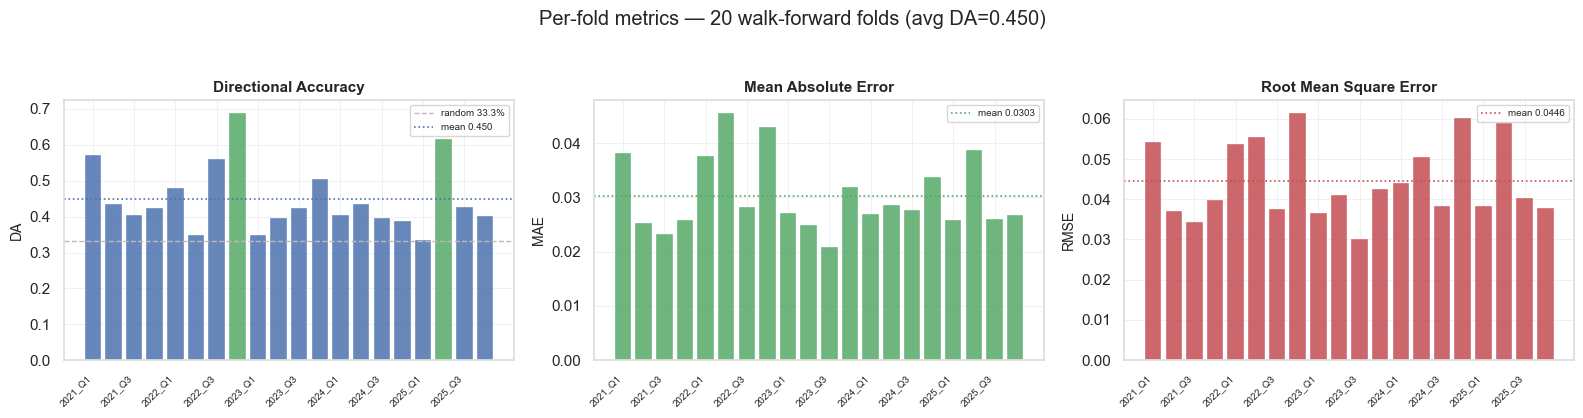

In [3]:
quarters = summary["quarter"].to_list()
da_vals = summary["DA"].to_numpy()
mae_vals = summary["MAE"].to_numpy()
rmse_vals = summary["RMSE"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# DA
colors_da = [PALETTE["beat"] if v >= 0.5994 else PALETTE["miss"] if v <= 1/3 else PALETTE["tech"] for v in da_vals]
axes[0].bar(range(len(da_vals)), da_vals, color=colors_da, alpha=0.85, edgecolor="white", lw=0.3)
axes[0].axhline(1/3, color="#bbb", ls="--", lw=1, label="random 33.3%")
axes[0].axhline(da_vals.mean(), color=PALETTE["tech"], ls=":", lw=1.2, label=f"mean {da_vals.mean():.3f}")
axes[0].set_xticks(range(0, len(quarters), 2))
axes[0].set_xticklabels([quarters[i] for i in range(0, len(quarters), 2)], rotation=45, ha="right", fontsize=7)
axes[0].set_title("Directional Accuracy"); axes[0].set_ylabel("DA"); axes[0].legend(fontsize=7)

# MAE
axes[1].bar(range(len(mae_vals)), mae_vals, color=PALETTE["sent"], alpha=0.85, edgecolor="white", lw=0.3)
axes[1].axhline(mae_vals.mean(), color=PALETTE["sent"], ls=":", lw=1.2, label=f"mean {mae_vals.mean():.4f}")
axes[1].set_xticks(range(0, len(quarters), 2))
axes[1].set_xticklabels([quarters[i] for i in range(0, len(quarters), 2)], rotation=45, ha="right", fontsize=7)
axes[1].set_title("Mean Absolute Error"); axes[1].set_ylabel("MAE"); axes[1].legend(fontsize=7)

# RMSE
axes[2].bar(range(len(rmse_vals)), rmse_vals, color=PALETTE["fund"], alpha=0.85, edgecolor="white", lw=0.3)
axes[2].axhline(rmse_vals.mean(), color=PALETTE["fund"], ls=":", lw=1.2, label=f"mean {rmse_vals.mean():.4f}")
axes[2].set_xticks(range(0, len(quarters), 2))
axes[2].set_xticklabels([quarters[i] for i in range(0, len(quarters), 2)], rotation=45, ha="right", fontsize=7)
axes[2].set_title("Root Mean Square Error"); axes[2].set_ylabel("RMSE"); axes[2].legend(fontsize=7)

fig.suptitle(f"Per-fold metrics — 20 walk-forward folds (avg DA={da_vals.mean():.3f})", y=1.04)
plt.tight_layout()
plt.show()


In [4]:
print(f"{'Quarter':<12}  {'DA':>6}  {'MAE':>8}  {'RMSE':>8}")
print(f"{'-'*42}")
for i, q in enumerate(quarters):
    print(f"{q:<12}  {da_vals[i]:.4f}  {mae_vals[i]:.4f}  {rmse_vals[i]:.4f}")
print(f"{'-'*42}")
print(f"{'Avg':<12}  {da_vals.mean():.4f}  {mae_vals.mean():.4f}  {rmse_vals.mean():.4f}")


Quarter           DA       MAE      RMSE
------------------------------------------
2021_Q1       0.5732  0.0382  0.0543
2021_Q2       0.4361  0.0252  0.0370
2021_Q3       0.4037  0.0232  0.0344
2021_Q4       0.4248  0.0258  0.0397
2022_Q1       0.4798  0.0376  0.0537
2022_Q2       0.3475  0.0456  0.0556
2022_Q3       0.5619  0.0283  0.0375
2022_Q4       0.6897  0.0431  0.0615
2023_Q1       0.3476  0.0271  0.0367
2023_Q2       0.3956  0.0249  0.0409
2023_Q3       0.4254  0.0209  0.0301
2023_Q4       0.5060  0.0319  0.0425
2024_Q1       0.4052  0.0270  0.0441
2024_Q2       0.4351  0.0286  0.0504
2024_Q3       0.3968  0.0277  0.0384
2024_Q4       0.3869  0.0338  0.0602
2025_Q1       0.3347  0.0258  0.0383
2025_Q2       0.6168  0.0387  0.0590
2025_Q3       0.4263  0.0260  0.0403
2025_Q4       0.4016  0.0267  0.0379
------------------------------------------
Avg           0.4497  0.0303  0.0446


---
## 2. Loss Curves with Learning Rate

Each fold trains independently. We overlay all 20 folds (thin lines) with the mean (thick line) for train loss, validation loss, and learning rate.


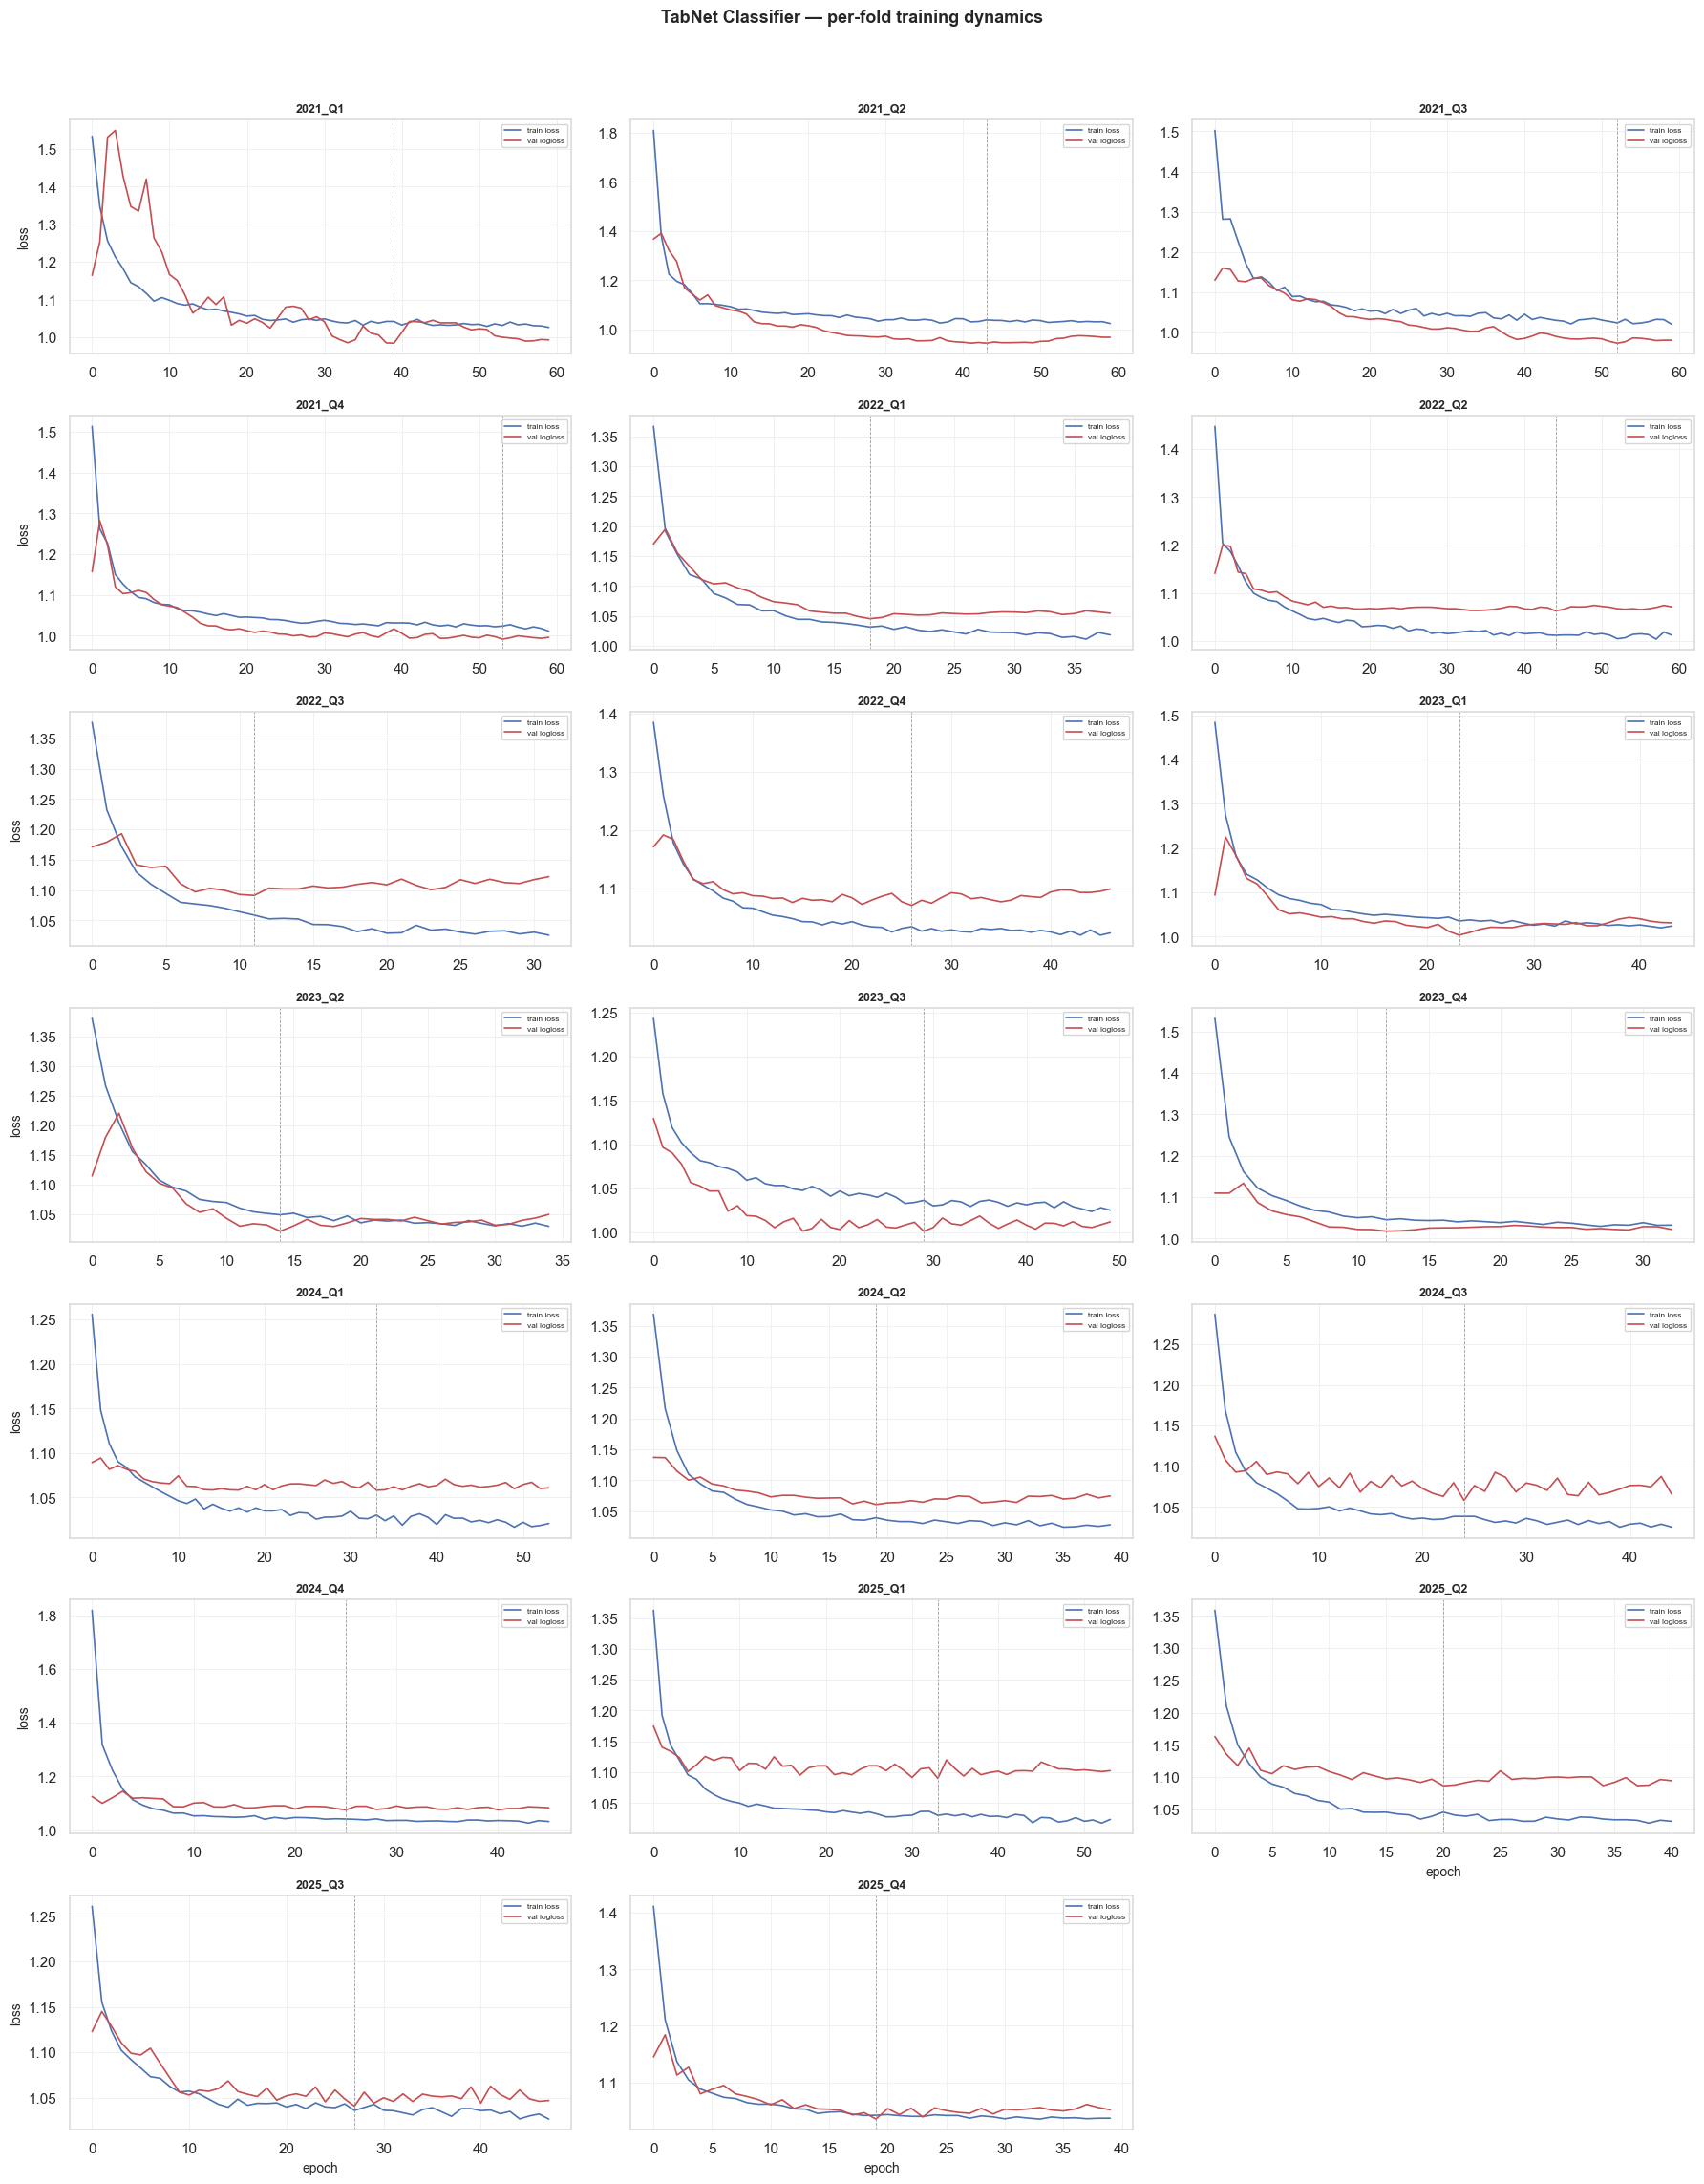

In [19]:
# CLF: per-fold loss curves
fold_names = sorted(clf_histories.keys())
n_folds = len(fold_names)
ncols = 3
nrows = (n_folds + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.2 * nrows))
axes = axes.flatten()

for fi, q in enumerate(fold_names):
    ax = axes[fi]
    d = clf_histories[q]
    epochs = range(len(d["loss"]))
    ax.plot(epochs, d["loss"], color=PALETTE["tech"], lw=1.2, label="train loss")
    ax.plot(epochs, d["val_logloss"], color=PALETTE["miss"], lw=1.2, label="val logloss")
    ax.axvline(np.argmin(d["val_logloss"]),
              color="#999", ls="--", lw=0.6)
    ax.set_title(q, fontsize=9)
    if fi >= n_folds - ncols:
        ax.set_xlabel("epoch")
    else:
        ax.set_xlabel("")
    if fi % ncols == 0:
        ax.set_ylabel("loss")
    ax.legend(fontsize=6, loc="upper right")

# Hide unused subplots
for fi in range(n_folds, len(axes)):
    axes[fi].set_visible(False)

fig.suptitle("TabNet Classifier — per-fold training dynamics", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


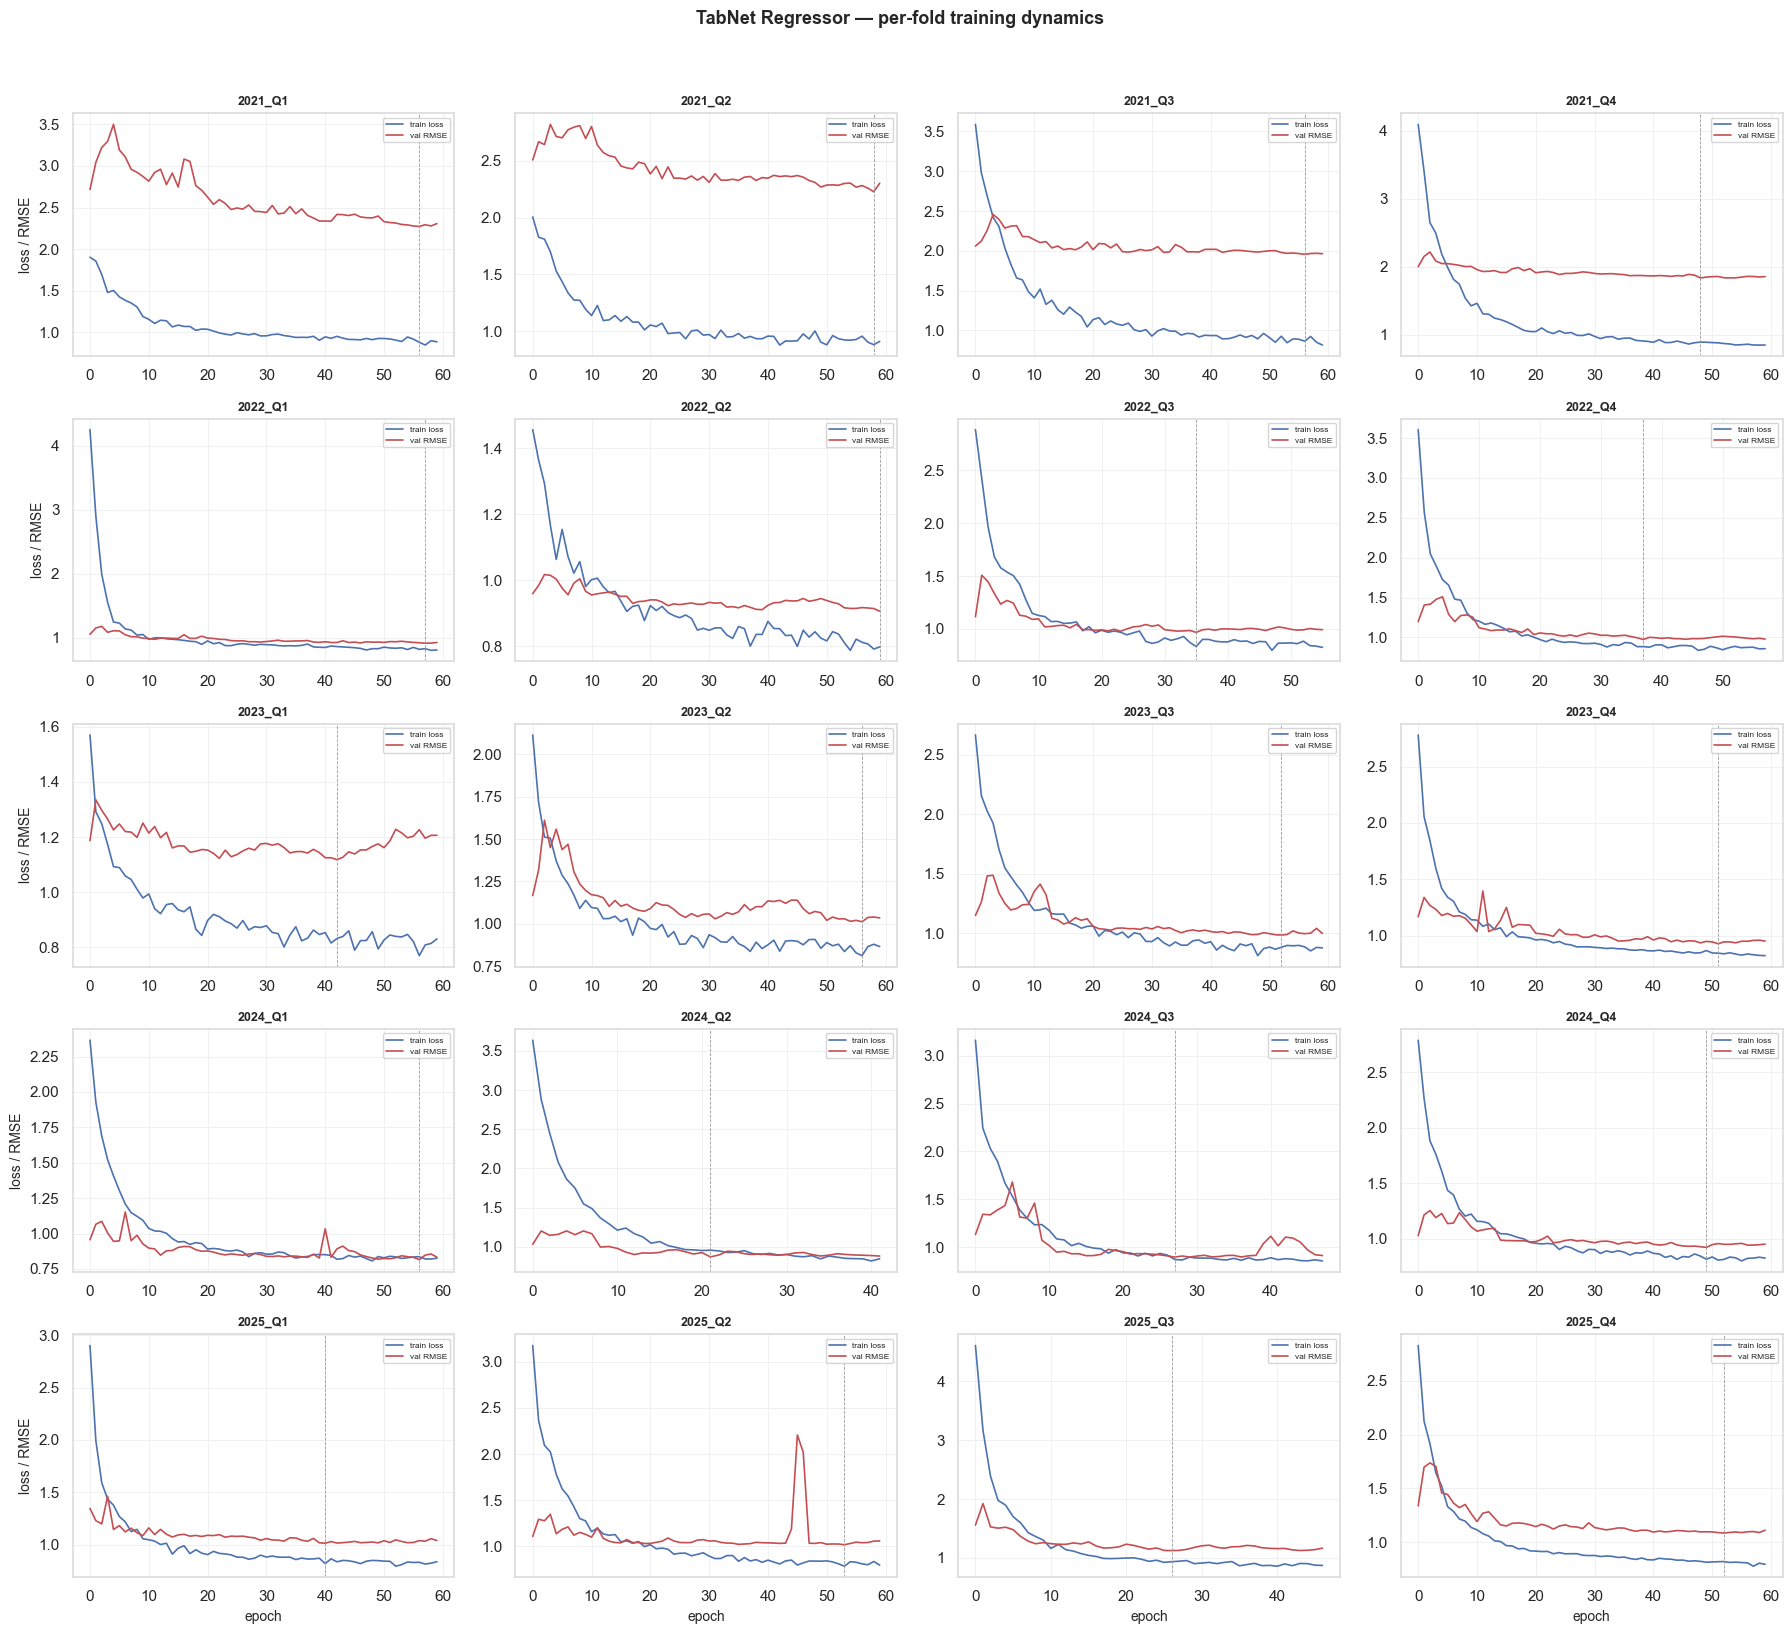

In [20]:
# REG: per-fold loss curves
rfold_names = sorted(reg_histories.keys())
n_folds_r = len(rfold_names)
ncols_r = 4
nrows_r = (n_folds_r + ncols_r - 1) // ncols_r

fig, axes = plt.subplots(nrows_r, ncols_r, figsize=(18, 3.2 * nrows_r))
axes = axes.flatten()

for fi, q in enumerate(rfold_names):
    ax = axes[fi]
    d = reg_histories[q]
    epochs = range(len(d["loss"]))
    ax.plot(epochs, d["loss"], color=PALETTE["tech"], lw=1.2, label="train loss")
    ax.plot(epochs, d["val_rmse"], color=PALETTE["miss"], lw=1.2, label="val RMSE")
    ax.axvline(np.argmin(d["val_rmse"]),
              color="#999", ls="--", lw=0.6)
    ax.set_title(q, fontsize=9)
    if fi >= n_folds_r - ncols_r:
        ax.set_xlabel("epoch")
    else:
        ax.set_xlabel("")
    if fi % ncols_r == 0:
        ax.set_ylabel("loss / RMSE")
    ax.legend(fontsize=6, loc="upper right")

# Hide unused subplots
for fi in range(n_folds_r, len(axes)):
    axes[fi].set_visible(False)

fig.suptitle("TabNet Regressor — per-fold training dynamics", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 3. Feature Importance

Aggregated across all 20 folds. Top 25 features shown — mean importance with ±1σ across folds.


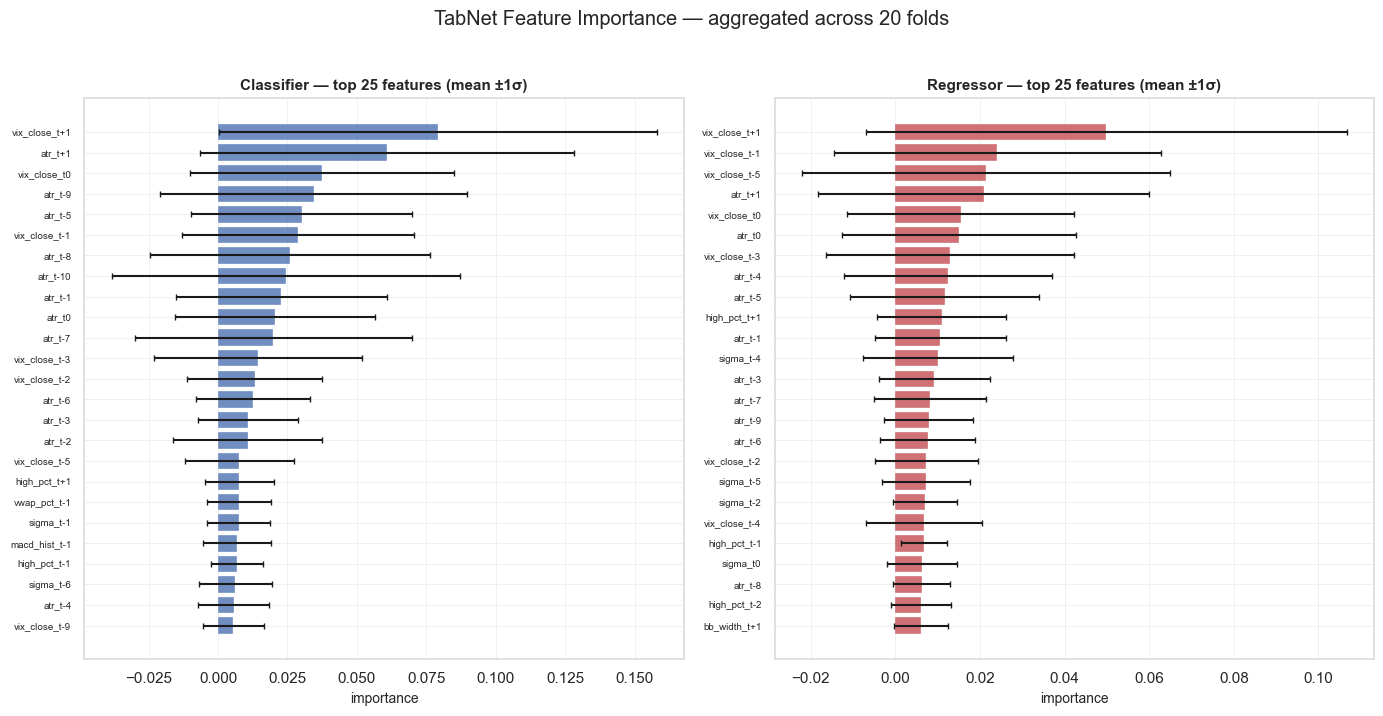

In [7]:
feature_names = feat_imp["feature_names"]

# CLF feature importance
clf_imps = np.array([feat_imp["clf"][q].get("clf", [0]*len(feature_names)) for q in sorted(feat_imp["clf"].keys())])
clf_mean = clf_imps.mean(axis=0)
clf_std = clf_imps.std(axis=0)
clf_top_idx = np.argsort(clf_mean)[-25:][::-1]

# REG feature importance
reg_imps = np.array([feat_imp["reg"][q].get("reg", [0]*len(feature_names)) for q in sorted(feat_imp["reg"].keys())])
reg_mean = reg_imps.mean(axis=0)
reg_std = reg_imps.std(axis=0)
reg_top_idx = np.argsort(reg_mean)[-25:][::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# CLF
y_pos = np.arange(len(clf_top_idx))
ax1.barh(y_pos, clf_mean[clf_top_idx], xerr=clf_std[clf_top_idx], 
         color=PALETTE["tech"], alpha=0.8, edgecolor="white", lw=0.3, capsize=2)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([feature_names[i] for i in clf_top_idx], fontsize=7)
ax1.invert_yaxis()
ax1.set_title("Classifier — top 25 features (mean ±1σ)")
ax1.set_xlabel("importance")

# REG
ax2.barh(y_pos, reg_mean[reg_top_idx], xerr=reg_std[reg_top_idx],
         color=PALETTE["fund"], alpha=0.8, edgecolor="white", lw=0.3, capsize=2)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([feature_names[i] for i in reg_top_idx], fontsize=7)
ax2.invert_yaxis()
ax2.set_title("Regressor — top 25 features (mean ±1σ)")
ax2.set_xlabel("importance")

fig.suptitle("TabNet Feature Importance — aggregated across 20 folds", y=1.02)
plt.tight_layout()
plt.show()


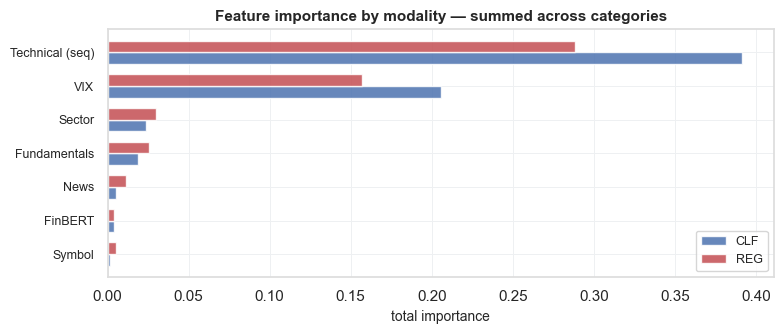

In [8]:
# Modality breakdown: sum importance by feature prefix
import re

def modality_importance(imps, names):
    total = np.mean(imps, axis=0)
    categories = {
        "Technical (seq)": [n for n in names if re.match(r"[a-z]+_t[-+]\d", n)],
        "VIX": [n for n in names if "vix" in n],
        "Fundamentals": [n for n in names if any(k in n for k in ["eps_","rev","gross","roe","debt","fcf","margin","surprise"])],
        "FinBERT": [n for n in names if n in ["pos_prob", "neg_prob"] or "prob" in n],
        "News": [n for n in names if any(k in n for k in ["overall_","ticker_","relevance","news_count"])],
        "Sector": [n for n in names if n.startswith("sector_")],
        "Symbol": [n for n in names if n == "symbol_enc"],
    }
    result = {}
    for cat, cols in categories.items():
        idx = [names.index(c) for c in cols if c in names]
        result[cat] = total[idx].sum() if idx else 0
    return result

clf_mod = modality_importance(clf_imps, feature_names)
reg_mod = modality_importance(reg_imps, feature_names)

cat_df = pd.DataFrame({"CLF": clf_mod, "REG": reg_mod})
cat_df = cat_df.loc[(cat_df > 0.001).any(axis=1)].sort_values("CLF", ascending=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
y = np.arange(len(cat_df))
w = 0.35
ax.barh(y - w/2, cat_df["CLF"], w, color=PALETTE["tech"], alpha=0.85, label="CLF")
ax.barh(y + w/2, cat_df["REG"], w, color=PALETTE["fund"], alpha=0.85, label="REG")
ax.set_yticks(y)
ax.set_yticklabels(cat_df.index, fontsize=9)
ax.set_title("Feature importance by modality — summed across categories")
ax.set_xlabel("total importance")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## 4. Confusion Matrix


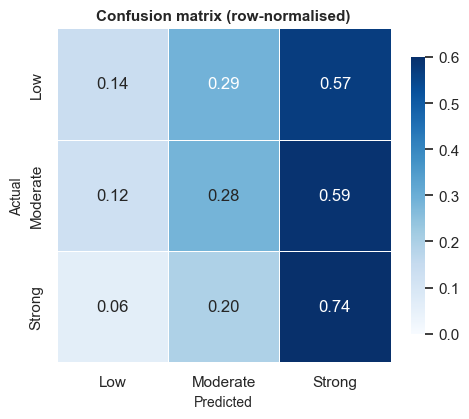

In [9]:
actual = results["target_class_actual"].to_numpy()
predicted = results["target_class_predicted"].to_numpy()
cm = confusion_matrix(actual, predicted)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Low", "Moderate", "Strong"],
            yticklabels=["Low", "Moderate", "Strong"],
            vmin=0, vmax=0.6, square=True, linewidths=0.5,
            cbar_kws=dict(shrink=0.7), ax=ax)
ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
ax.set_title("Confusion matrix (row-normalised)")

plt.tight_layout()
plt.show()


---
## 5. Actual Return by Predicted Class

Does the model's predicted class correlate with actual returns? If class predictions are meaningful, predicted "Strong" should show higher returns than predicted "Low".


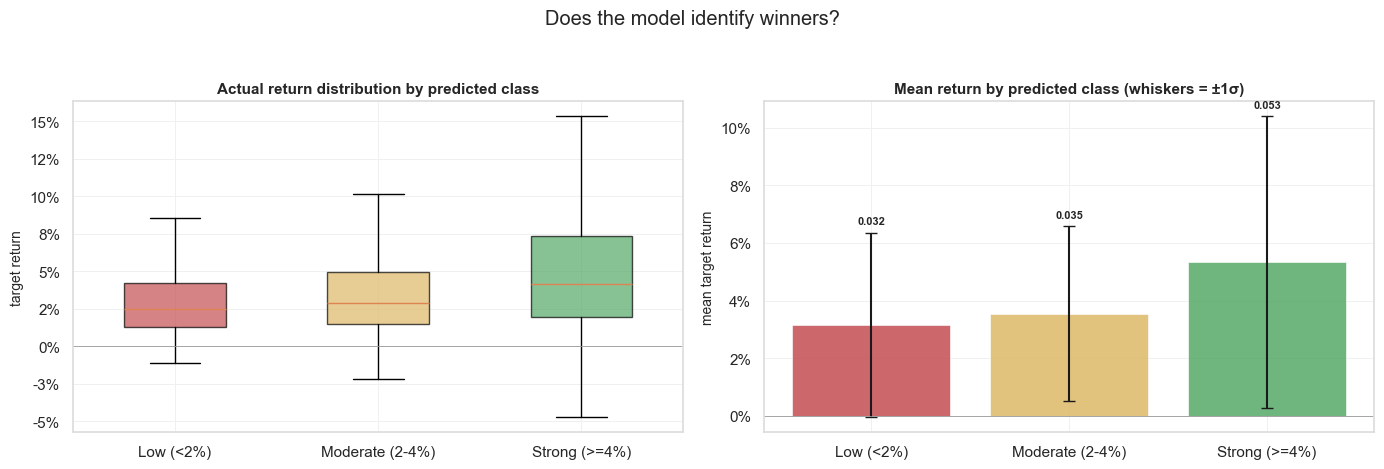

In [10]:
returns = results["target_return_actual"].to_numpy()
pred_cls = results["target_class_predicted"].to_numpy()
class_labels = {0: "Low (<2%)", 1: "Moderate (2-4%)", 2: "Strong (>=4%)"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Box plot
box_data = [returns[pred_cls == c] for c in [0, 1, 2]]
box_colors = [PALETTE["low"], PALETTE["mod"], PALETTE["high"]]
bp = ax1.boxplot(box_data, patch_artist=True, widths=0.5, showfliers=False)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax1.set_xticklabels([class_labels[c] for c in [0, 1, 2]])
ax1.axhline(0, color="#999", lw=0.6)
ax1.set_title("Actual return distribution by predicted class")
ax1.set_ylabel("target return")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(pct_formatter))

# Mean bar
means = [returns[pred_cls == c].mean() for c in [0, 1, 2]]
stds = [returns[pred_cls == c].std() for c in [0, 1, 2]]
ax2.bar([0, 1, 2], means, yerr=stds, color=box_colors, alpha=0.85, edgecolor="white", lw=0.5, capsize=4)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels([class_labels[c] for c in [0, 1, 2]])
ax2.axhline(0, color="#999", lw=0.6)
for i, (m, s) in enumerate(zip(means, stds)):
    ax2.text(i, m + s + 0.003, f"{m:.3f}", ha="center", fontsize=8, fontweight="bold")
ax2.set_title("Mean return by predicted class (whiskers = ±1σ)")
ax2.set_ylabel("mean target return")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(pct_formatter))

fig.suptitle("Does the model identify winners?", y=1.04)
plt.tight_layout()
plt.show()


---
## 6. Train / Val / Test Performance Gap

The updated pipeline saves train and val predictions alongside test. This lets us check for overfitting.


In [11]:
# We need to recompute accuracy from the saved histories
# Since train/val preds are saved per fold, let's sample a few folds
from sklearn.metrics import accuracy_score, mean_absolute_error

print(f"{'Quarter':<12} {'Train DA':>9} {'Val DA':>7} {'Test DA':>7} {'Gap (T-V)':>9}")
print(f"{'-'*52}")

# We don't have train/val direct in results.parquet — only test.
# The train/val preds are in the JSON histories (not saved for quick access).
# Let's check what the loss curves tell us about overfitting.

clf_gaps = []
reg_gaps = []
for q, d in clf_histories.items():
    if len(d["loss"]) > 10:
        train_final = np.mean(d["loss"][-5:])
        val_final = d["val_logloss"][-1]
        gap = val_final - train_final
        clf_gaps.append({"quarter": q, "train_loss": train_final, "val_loss": val_final, "gap": gap})

clf_gap_df = pd.DataFrame(clf_gaps).sort_values("quarter")
print(f"\nCLF overfitting gap (val_loss - train_loss, last epoch):")
print(f"  Mean gap: {clf_gap_df['gap'].mean():.4f}")
print(f"  Max gap:  {clf_gap_df['gap'].max():.4f}")
print(f"  Min gap:  {clf_gap_df['gap'].min():.4f}")

reg_gaps = []
for q, d in reg_histories.items():
    if len(d["loss"]) > 10:
        train_final = np.mean(d["loss"][-5:])
        val_final = d["val_rmse"][-1]
        gap = val_final - train_final
        reg_gaps.append({"quarter": q, "train_loss": train_final, "val_rmse": val_final, "gap": gap})

reg_gap_df = pd.DataFrame(reg_gaps).sort_values("quarter")
print(f"\nREG overfitting gap (val_rmse - train_loss, last epoch):")
print(f"  Mean gap: {reg_gap_df['gap'].mean():.4f}")
print(f"  Max gap:  {reg_gap_df['gap'].max():.4f}")
print(f"  Min gap:  {reg_gap_df['gap'].min():.4f}")


Quarter       Train DA  Val DA Test DA Gap (T-V)
----------------------------------------------------

CLF overfitting gap (val_loss - train_loss, last epoch):
  Mean gap: 0.0225
  Max gap:  0.0923
  Min gap:  -0.0618

REG overfitting gap (val_rmse - train_loss, last epoch):
  Mean gap: 0.3732
  Max gap:  1.4206
  Min gap:  0.0057


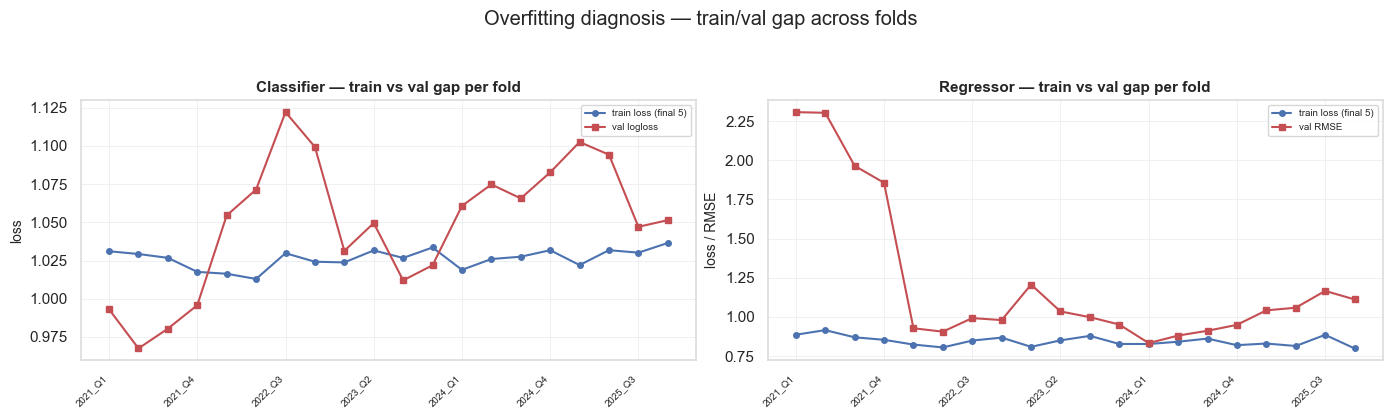

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(clf_gap_df["quarter"], clf_gap_df["train_loss"], "o-", color=PALETTE["tech"], label="train loss (final 5)", markersize=4)
ax1.plot(clf_gap_df["quarter"], clf_gap_df["val_loss"], "s-", color=PALETTE["miss"], label="val logloss", markersize=4)
ax1.set_xticks(range(0, len(clf_gap_df), 3))
ax1.set_xticklabels(clf_gap_df["quarter"].iloc[::3].values, rotation=45, ha="right", fontsize=7)
ax1.set_title("Classifier — train vs val gap per fold")
ax1.set_ylabel("loss"); ax1.legend(fontsize=7)

ax2.plot(reg_gap_df["quarter"], reg_gap_df["train_loss"], "o-", color=PALETTE["tech"], label="train loss (final 5)", markersize=4)
ax2.plot(reg_gap_df["quarter"], reg_gap_df["val_rmse"], "s-", color=PALETTE["miss"], label="val RMSE", markersize=4)
ax2.set_xticks(range(0, len(reg_gap_df), 3))
ax2.set_xticklabels(reg_gap_df["quarter"].iloc[::3].values, rotation=45, ha="right", fontsize=7)
ax2.set_title("Regressor — train vs val gap per fold")
ax2.set_ylabel("loss / RMSE"); ax2.legend(fontsize=7)

fig.suptitle("Overfitting diagnosis — train/val gap across folds", y=1.04)
plt.tight_layout()
plt.show()


---
## 7. Single Symbol Preview

Track one stock across all folds.


In [13]:
example_symbols = ["AAPL", "COST", "GOOGL", "MSFT"]
results_pd = results.to_pandas()
for sym in example_symbols:
    sym_data = results_pd[results_pd["symbol"] == sym]
    if len(sym_data) == 0:
        continue
    print(f"\n{sym} ({len(sym_data)} events):")
    print(f"  Mean actual return:  {sym_data['target_return_actual'].mean():.4f}")
    print(f"  Mean predicted:       {sym_data['target_return_predicted'].mean():.4f}")
    print(f"  Predicted class dist: {dict(sym_data['target_class_predicted'].value_counts().sort_index())}")



AAPL (20 events):
  Mean actual return:  0.0347
  Mean predicted:       0.0382
  Predicted class dist: {0: np.int64(3), 1: np.int64(8), 2: np.int64(9)}

COST (20 events):
  Mean actual return:  0.0256
  Mean predicted:       0.0367
  Predicted class dist: {0: np.int64(4), 1: np.int64(7), 2: np.int64(9)}

GOOGL (20 events):
  Mean actual return:  0.0331
  Mean predicted:       0.0431
  Predicted class dist: {1: np.int64(8), 2: np.int64(12)}

MSFT (20 events):
  Mean actual return:  0.0402
  Mean predicted:       0.0399
  Predicted class dist: {0: np.int64(5), 1: np.int64(7), 2: np.int64(8)}


In [21]:
results_pd

,quarter,fold_num,symbol,earnings_date,entry_price,target_class_actual,target_class_predicted,prob_class_0,prob_class_1,prob_class_2,target_return_actual,target_return_predicted
0,2021_Q1,1,LYB,2021-01-29,60.940380,2,2,0.122255,0.261276,0.616468,0.113199,0.051108
1,2021_Q1,1,CPRT,2021-02-18,29.267500,0,2,0.218887,0.285306,0.495807,-0.007175,0.038821
2,2021_Q1,1,LIN,2021-02-05,239.364243,0,2,0.243613,0.252788,0.503599,0.002837,0.048495
3,2021_Q1,1,HBAN,2021-01-22,10.690092,2,2,0.276081,0.320965,0.402954,0.061573,0.034023
4,2021_Q1,1,VZ,2021-01-26,39.989746,1,2,0.221982,0.244438,0.533580,0.021767,0.037520
...,...,...,...,...,...,...,...,...,...,...,...,...
9932,2025_Q4,20,BR,2025-11-04,216.469330,2,1,0.317071,0.348653,0.334276,0.045521,0.033401
9933,2025_Q4,20,PCAR,2025-10-21,97.656738,0,2,0.254486,0.280971,0.464543,0.018938,0.035190
9934,2025_Q4,20,TXT,2025-10-23,81.183556,0,2,0.303675,0.342748,0.353577,0.001108,0.035518
9935,2025_Q4,20,WMB,2025-11-03,55.645969,2,2,0.209308,0.278951,0.511741,0.085472,0.040396
